In [1]:
from fenicsviz import fenicsModel, _plot_fenics_function_on_ax
from fenics import *
from matplotlib import pyplot as plt
import numpy as np

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [115]:
fm = fenicsModel(alpha=0.1, n=16)

In [116]:
fm.objective

2.0472907464399825

In [117]:
fm.compliance

0.8958779054538347

In [118]:
fm.tv

184.22605455778367

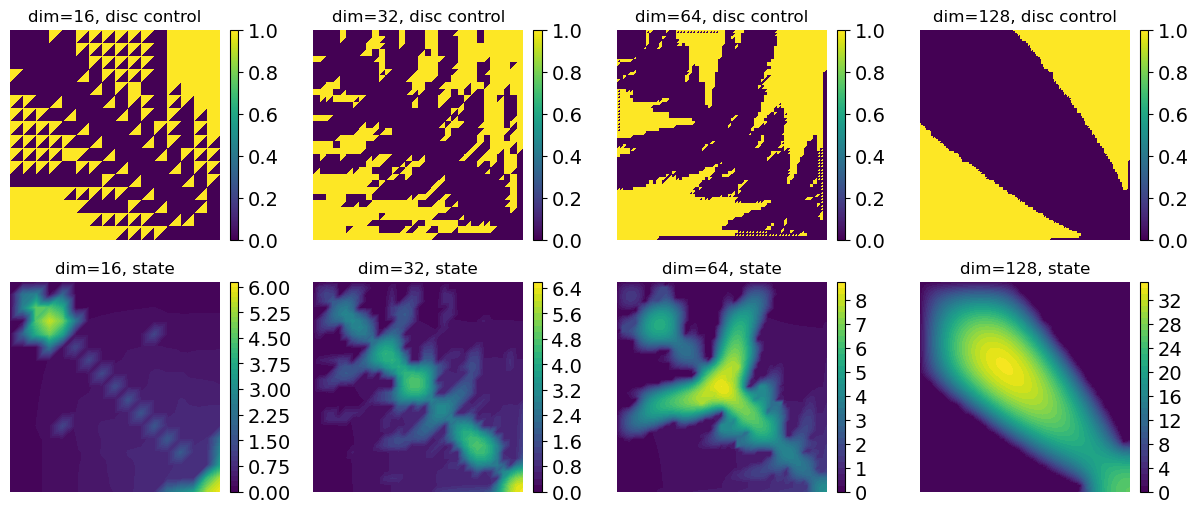

In [2]:
mesh_list = [16,32,64,128]
fig,ax = plt.subplots(figsize=(15,6), nrows=2, ncols=4)
for i, mesh in enumerate(mesh_list):
    fm = fenicsModel(alpha=0.01, n=mesh, base_dir="fenics_model_tri")
    c = fm.control
    s = fm.state
    _plot_fenics_function_on_ax(c, ax=ax[0][i], title=f"dim={mesh}, disc control")
    _plot_fenics_function_on_ax(s, ax=ax[1][i], title=f"dim={mesh}, state")

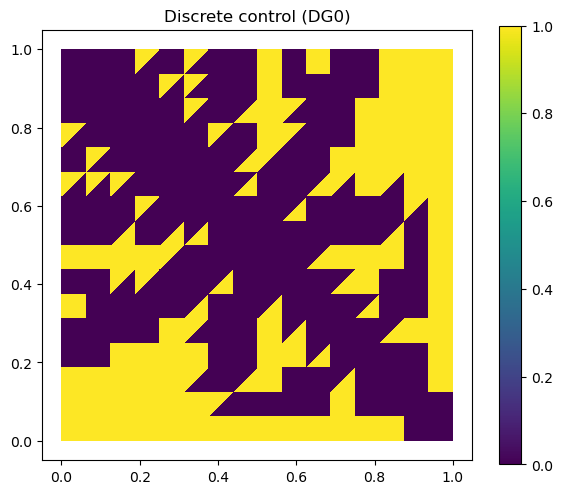

In [120]:
fm.plot_control()          # discrete control (DG0)

In [36]:
import networkx as nx
import math

In [91]:
import numpy as np

num = 128
mesh = UnitSquareMesh(num,num)
dummy = np.zeros(2*num**2)
dummy[0] = dummy[1] = dummy[-1] = 1
#dummy[0] = dummy[-1]  = 1 
X = FunctionSpace(mesh, "DG", 0)
x = Function(X)
dS = Measure("dS", domain=mesh)
x.vector().set_local(dummy)
jmp = assemble(sqrt((jump(x)**2) + 1e-12)*dS)
print(jmp)

0.03492102830601791


In [92]:
def _build_graph(mesh):
        G = nx.Graph()
        num_cells = mesh.num_cells()
        G.add_nodes_from(range(num_cells))

        # get the connectivity: cell → facets → neighboring cells
        mesh.init(2, 1)
        mesh.init(1, 2)

        for cell in cells(mesh):
            cid = cell.index()
            for facet in facets(cell):
                for neighbor in facet.entities(2):
                    if neighbor != cid:
                        G.add_edge(cid, neighbor)

        return G

In [93]:
graph = _build_graph(mesh)

In [94]:
scale = np.zeros(len(graph.edges()))
for k, (u, v) in enumerate(graph.edges()):
            scale[k] = math.sqrt(2) if abs(u - v) == 1 else 1.0

In [95]:
def compute_TV(graph, a, b, lam, rho):
        """Total variation term at (a,b,lam,rho)"""
        # note: lam, rho arent used here  but signature stays same
        diffs = []
        for (u, v), s in zip(graph.edges(), scale):
            diffs.append(s * abs(a[u] - a[v]))
        Gg = sum(diffs)
        return Gg

In [96]:
tv = compute_TV(graph, c.vector().get_local(), c.vector().get_local(), None, None)
print(tv)

302.38477631085027


In [ ]:
compute_TV(c, c, None, None)

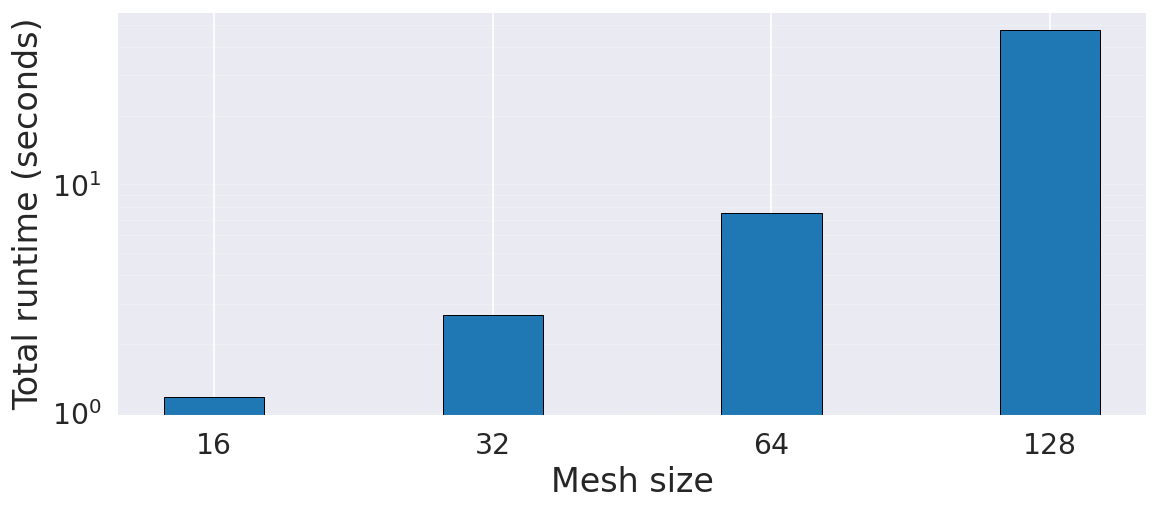

mesh= 16 | runtime=1.173e+00 s
mesh= 32 | runtime=2.688e+00 s
mesh= 64 | runtime=7.505e+00 s
mesh=128 | runtime=4.732e+01 s


In [3]:
# Runtime comparison across mesh sizes
mesh_sizes = [16, 32, 64, 128]
base_dir = "fenics_model_tri"
alpha = 0.01

runtime = []

for mesh in mesh_sizes:
    fm = fenicsModel(alpha=alpha, n=mesh, base_dir=base_dir)
    runtime.append(float(fm.runtime_total))

runtime = np.asarray(runtime, dtype=float)


# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,

    # line/bar style
    "lines.linewidth": 2.8,
    "lines.markersize": 6,

    # global font sizes
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.title_fontsize": 17,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
color_runtime = cmap(0)


x = np.arange(len(mesh_sizes))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x,
    runtime,
    width=width,
    color=color_runtime,
    edgecolor="black",
    linewidth=0.6,
    label="Total runtime",
)

ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in mesh_sizes])
ax.set_xlabel("Mesh size")
ax.set_ylabel("Total runtime (seconds)")
ax.set_yscale("log")

ax.grid(
    True,
    axis="y",
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# ax.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, 0.14),
#     ncol=1,
#     frameon=True,
# )

plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()


for mesh, r in zip(mesh_sizes, runtime):
    print(f"mesh={mesh:>3} | runtime={r:.3e} s")